# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
DS = Dataset('Fe-Mo')

In [5]:
ModelName = 'MLP'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


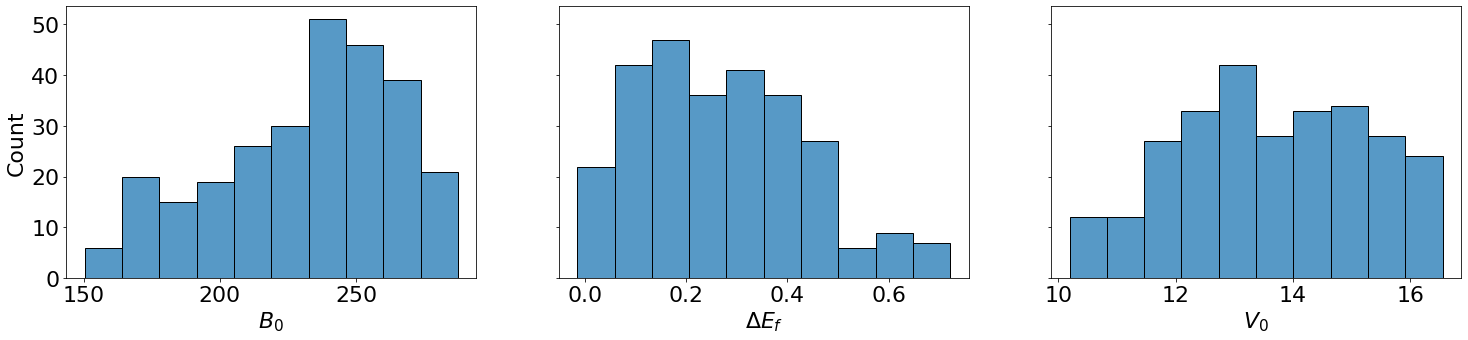

In [6]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions.eps')

# Machine Learning 

In [7]:
from Tools.DatasetTools.MLConveniences import *

In [8]:
resultslocation = DS.resultslocation

## Feature sets

In [9]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [10]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8Mo_sv22.sigma-BBABB.FM,10,0,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.420953
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10,0,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,...,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000,0.771907
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,0,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,...,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327,0.843636
Fe_pv5Mo_sv24.chi-AABB.FM,6,0,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,...,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205,0.400003
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,1,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,...,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607,0.211655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,9,1,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,...,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884,0.595930
Fe_pv8Mo_sv22.sigma-BBABB.NM,10,1,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.150928
Fe_pv1Mo_sv3.L12-AB3.FM,7,0,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,...,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000,0.306685
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10,0,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.811522


In [11]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [12]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [13]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [14]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [15]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name) } )

In [16]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [17]:
samplesplit = DS.get_samplesplit()

# Models: adjust params

In [18]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())])
}

In [19]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [20]:
MO.load_model_options(ModelName)

In [21]:
MO.modeloptions[ModelName]

{'regressor__random_state': [20091116],
 'regressor__max_iter': [1000],
 'regressor__alpha': [0.03, 0.04, 0.05, 0.06, 0.1],
 'regressor__learning_rate': ['adaptive'],
 'regressor__learning_rate_init': [0.001],
 'regressor__activation': ['logistic'],
 'regressor__hidden_layer_sizes': [[20, 4], [40, 4]],
 'regressor__solver': ['lbfgs']}

In [22]:
samplefolds = list(DS.get_folds())

# fits

In [23]:
fittedmodelslocation = os.path.join(DS.resultslocation, f'{ModelName}_FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)
else:
    FittedModels = {}

In [24]:
for name, model in Models.items():
    if name not in ModelName:
        print (name)
        continue
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

Kernel Ridge


  0%|          | 0/19 [00:00<?, ?it/s]

Random Forest


In [25]:
with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

In [26]:
best_scores = collect_best_scores(FittedModels)

In [27]:
best_combi = best_scores.idxmin()['test']

In [28]:
best_combi

('MLP', 'Projections BOP')

In [29]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)

In [30]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [31]:
best_scores.loc[best_combi]

test     0.045987
train    0.027082
Name: (MLP, Projections BOP), dtype: float64

In [32]:
results.loc[7].params

{'regressor__activation': 'logistic',
 'regressor__alpha': 0.06,
 'regressor__hidden_layer_sizes': [40, 4],
 'regressor__learning_rate': 'adaptive',
 'regressor__learning_rate_init': 0.001,
 'regressor__max_iter': 1000,
 'regressor__random_state': 20091116,
 'regressor__solver': 'lbfgs'}

for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

In [33]:
FittedModels[best_combi].best_params_

{'regressor__activation': 'logistic',
 'regressor__alpha': 0.06,
 'regressor__hidden_layer_sizes': [40, 4],
 'regressor__learning_rate': 'adaptive',
 'regressor__learning_rate_init': 0.001,
 'regressor__max_iter': 1000,
 'regressor__random_state': 20091116,
 'regressor__solver': 'lbfgs'}

In [34]:
best_scores

test     train
MLP Projections BOP                0.045987  0.027082
    Projections sOS BOP            0.046313  0.028295
    dataset + Projections BOP      0.046469  0.026138
    dataset + Projections sOS BOP  0.047217  0.026764
    Projections OS BOP             0.049549  0.027499
    dataset + Projections OS BOP   0.050516  0.027896
    dataset + Canonical BOP        0.051715  0.027664
    Canonical BOP                  0.064967  0.035016
    dataset                        0.079113  0.038819
    Pyscal                         0.156031  0.146370
    atomic                         0.168560  0.142985

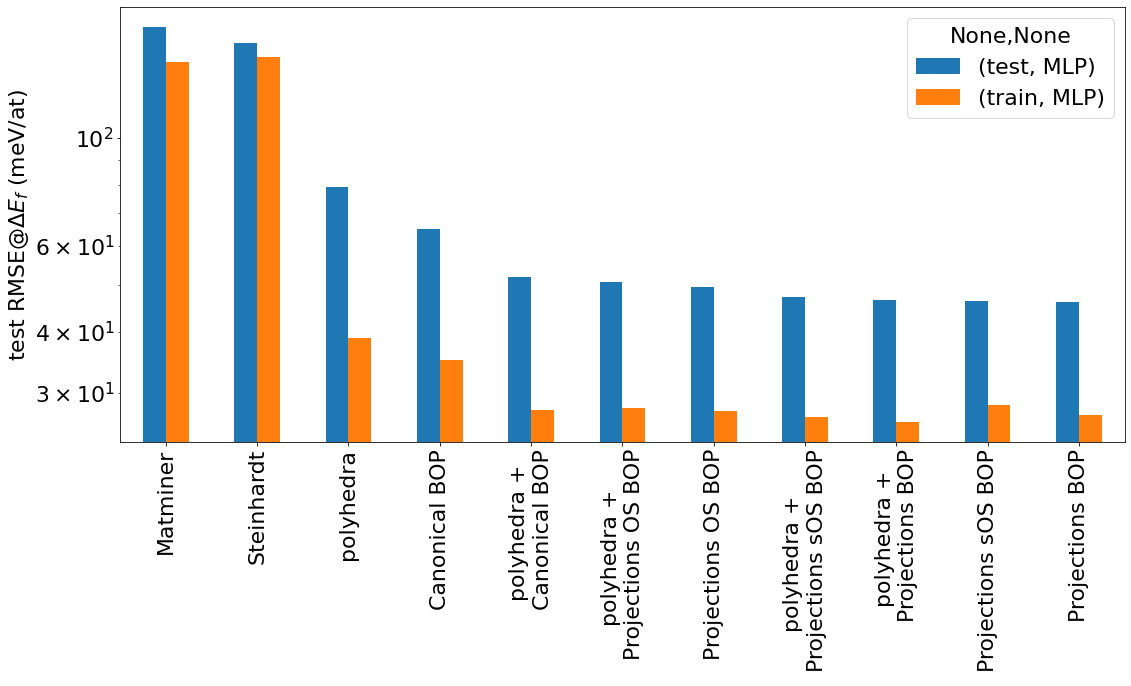

In [35]:
ax = plot_best_scores(best_scores, ModelName=ModelName)

# Recursivity

In [36]:
Tester = DatasetTester()

In [37]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [38]:
import copy

In [39]:
RecursivityModels = copy.deepcopy(FittedModels)

In [40]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Tools/DatasetTools/DatasetOperator.py:219: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes.plot(


(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

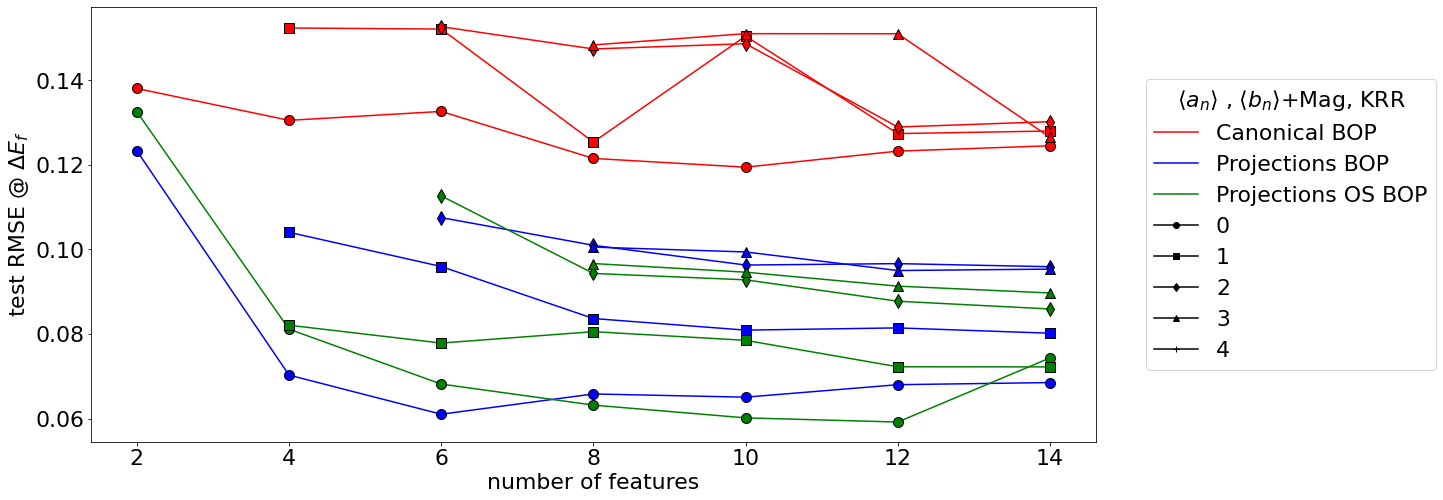

In [41]:
Tester.plot_recursivity_curve(test_scores, ModelName, )

In [42]:
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{ModelName}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [43]:
ReducedFittedModels = {}

In [44]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, 'ReducedFeaturesCVSearch.pkl')

In [45]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [46]:
MO.modeloptions

{'MLP': {'regressor__random_state': [20091116],
  'regressor__max_iter': [1000],
  'regressor__alpha': [0.03, 0.04, 0.05, 0.06, 0.1],
  'regressor__learning_rate': ['adaptive'],
  'regressor__learning_rate_init': [0.001],
  'regressor__activation': ['logistic'],
  'regressor__hidden_layer_sizes': [[20, 4], [40, 4]],
  'regressor__solver': ['lbfgs']}}

In [47]:
maxorders = [8,10,12,14,16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  #maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/95 [00:00<?, ?it/s]

In [48]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [49]:
somecombi = (ModelName, 'Projections BOP')

In [50]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [51]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [52]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [53]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [54]:
model = best_scores_reduced.index.get_level_values(0)

In [55]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [56]:
test_scores_vs_max[ModelName]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.045190,0.049304,0.046674,0.046022,0.050817,0.046039
10,0.045219,0.049818,0.044921,0.045405,0.049841,0.045148
12,0.045985,0.050348,0.045439,0.045753,0.050484,0.046024
14,0.045148,0.048169,0.045668,0.046293,0.050222,0.046234
16,0.045535,0.049365,0.045455,0.046200,0.050757,0.046854


In [57]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


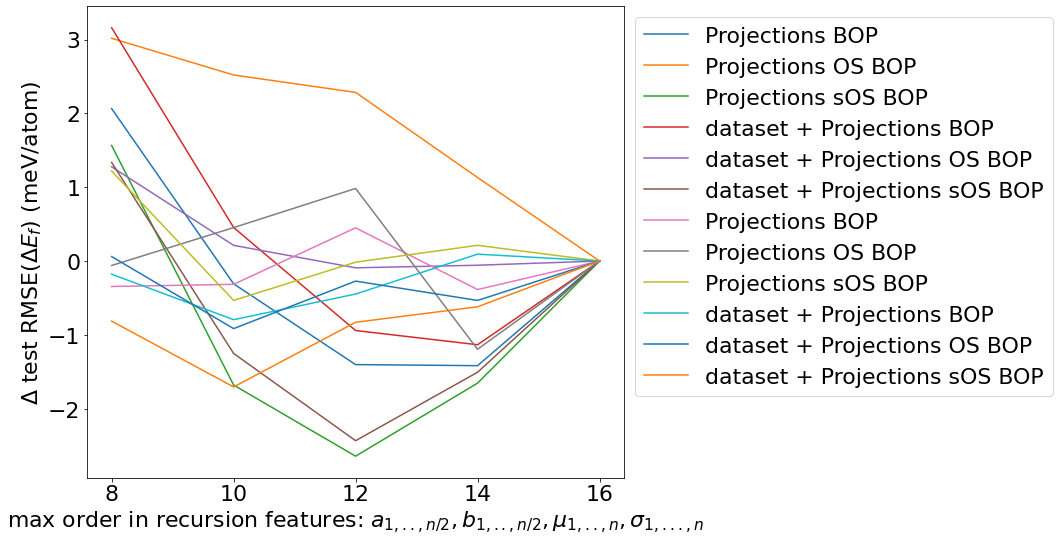

In [58]:
fig, ax = plt.subplots(figsize=(15,8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values -test_scores_vs_max[combi].values[-1])*1000 #- full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index,drmse , label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1,1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity.eps'))

# Feature Concatenation 

In [59]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().NewFeatureConcatenate
#from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate

In [60]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', 'concatenation_results.pkl')
if os.path.exists(feature_concat_resul_loc):
    with open (feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)

In [61]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'Projections BOP'), ('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'Projections OS BOP'), ('Kernel Ridge', 'dataset + Projections BOP'), ('Kernel Ridge', 'dataset + Projections OS BOP'), ('Kernel Ridge', 'Pyscal'), ('Kernel Ridge', 'Projections sOS BOP'), ('Kernel Ridge', 'dataset + Canonical BOP'), ('Kernel Ridge', 'dataset + Projections sOS BOP'), ('MLP', 'atomic'), ('MLP', 'dataset'), ('MLP', 'Pyscal'), ('MLP', 'Canonical BOP'), ('MLP', 'Projections BOP'), ('MLP', 'Projections OS BOP'), ('MLP', 'Projections sOS BOP'), ('MLP', 'dataset + Canonical BOP'), ('Random Forest', 'dataset')])

In [ ]:
for combi, fmodel in FittedModels.items(): # DS.Features.keys(): #['Canonical BOP']:
    if ModelName not in combi:
        continue
    model = copy.deepcopy(fmodel.best_estimator_)
    if combi in FCresults.keys():
        continue
    FC =  FeatureConcatenate(DS, model, fmodel.best_params_,)
    FCresults[combi] = FC.get_best_features_list(combi[1])
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

In [63]:
from Tools.DatasetTools.Tools import get_str_formatted

In [64]:
#iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'Projections OS BOP', 'Projections sOS BOP' ]

In [65]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [66]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

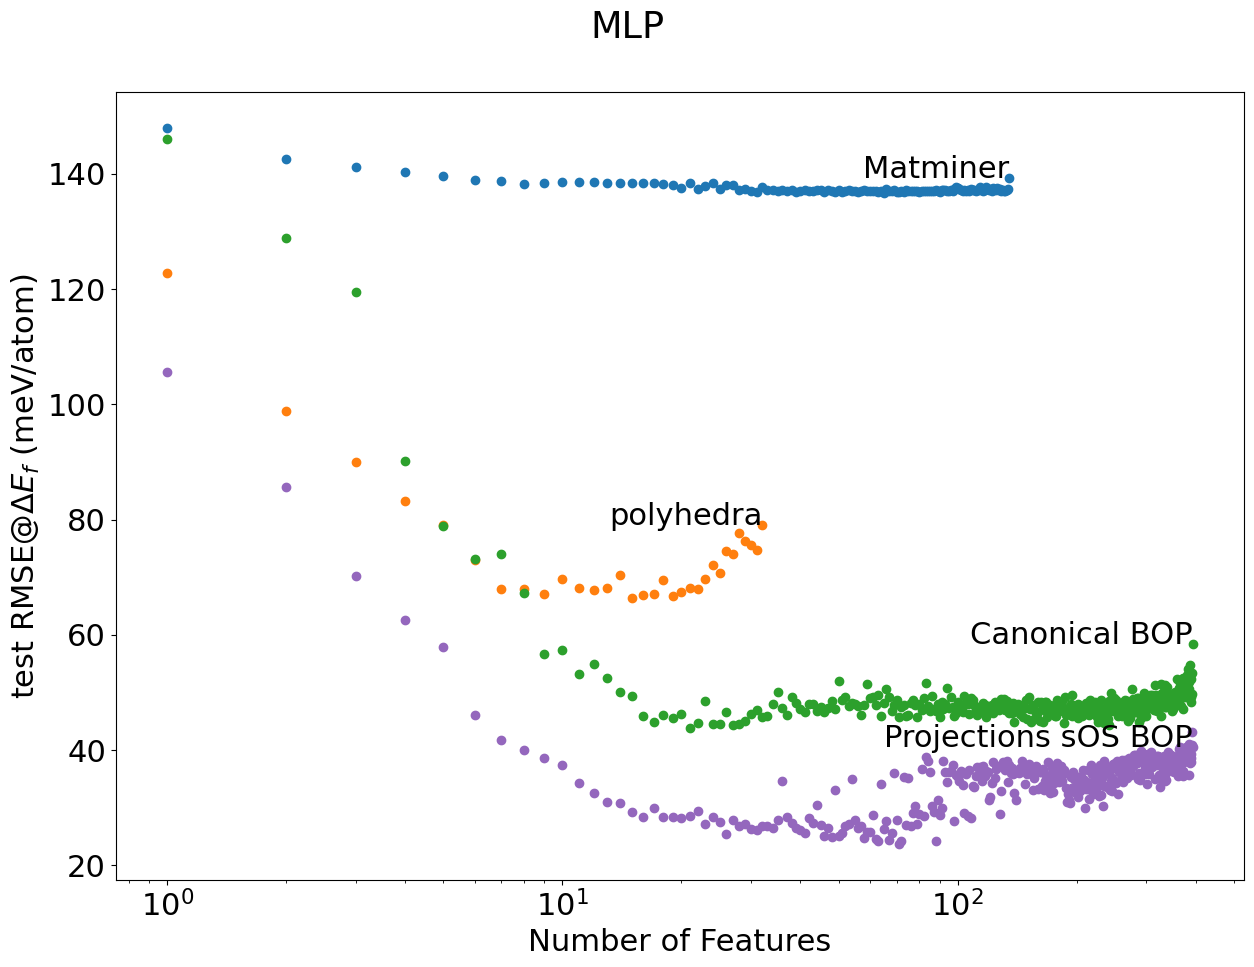

In [67]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(figsize=(13,10))
for combi, result in FCresults.items():
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if ' OS ' in combi[1]:
        continue
    nfeats = result.shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')
    y = result['test']*1000
    axes.plot(x, y ,'o',c=colors[combi[1]], label=legend)
    axes.text(x[-1], y[-1], legend, horizontalalignment='right')
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
fig.suptitle(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves.eps')

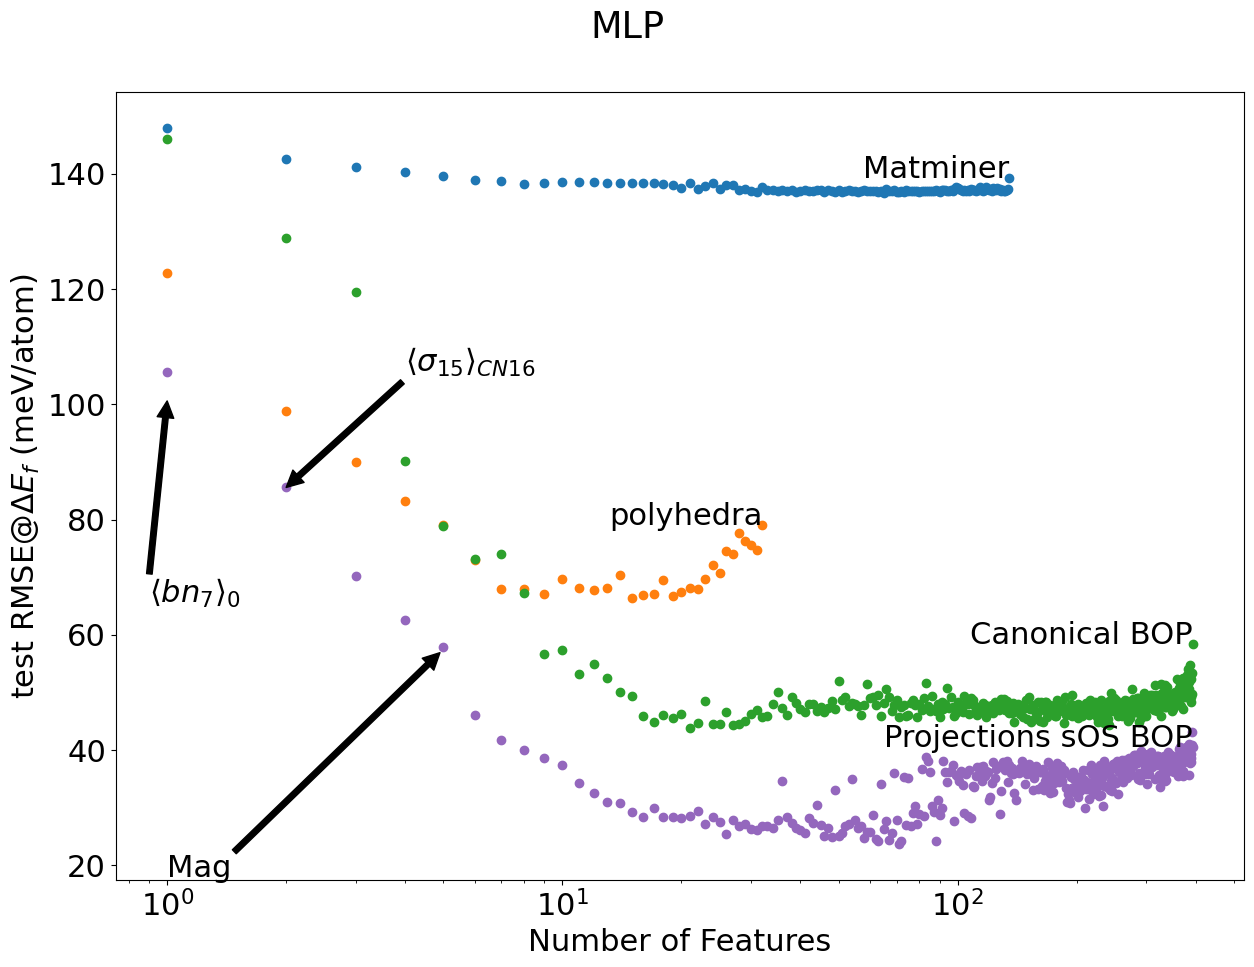

In [68]:
selected_pos = FCresults[(ModelName, 'Projections sOS BOP')].index[0]
y_pos = FCresults[(ModelName, 'Projections sOS BOP')]['test']*1000
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[(ModelName, 'Projections sOS BOP')].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-40), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated.eps')
fig

## selections

In [69]:
FCresults[(ModelName, 'Projections sOS BOP')].iloc[:20].index

Index(['bn_7_0', 'sigma_15_CN16', 'sigma_8_0', 'normed_moments_10_CN14', 'Mag',
       'sigma_9_0', 'sigma_4_0', 'normed_moments_13_0',
       'normed_moments_14_CN12', 'sigma_10_CN14', 'sigma_4_CN15',
       'U_bond_atom_list_1_0', 'sigma_13_0', 'moments_14_CN14',
       'normed_moments_11_0', 'sigma_7_0', 'bn_4_CN13', 'sigma_4_CN14',
       'an_1_0', 'normed_moments_12_CN12'],
      dtype='object')

# Final learn after feature selection 

In [70]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'Projections BOP'), ('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'Projections OS BOP'), ('Kernel Ridge', 'dataset + Projections BOP'), ('Kernel Ridge', 'dataset + Projections OS BOP'), ('Kernel Ridge', 'Pyscal'), ('Kernel Ridge', 'Projections sOS BOP'), ('Kernel Ridge', 'dataset + Canonical BOP'), ('Kernel Ridge', 'dataset + Projections sOS BOP'), ('MLP', 'atomic'), ('MLP', 'dataset'), ('MLP', 'Pyscal'), ('MLP', 'Canonical BOP'), ('MLP', 'Projections BOP'), ('MLP', 'Projections OS BOP'), ('MLP', 'Projections sOS BOP'), ('MLP', 'dataset + Canonical BOP'), ('Random Forest', 'dataset')])

In [71]:
OptimalFittedScores = {}
OptimalFittedModels = {}

In [72]:
Models[ModelName]

Pipeline(steps=[('scaler', StandardScaler()), ('regressor', MLPRegressor())])

In [73]:
for combi in FCresults.keys():
    if ModelName not in combi:
        continue
    OptimalFittedModels[combi]  = copy.deepcopy(Models[ModelName])
    params = FittedModels[combi].best_params_
    OptimalFittedModels[combi].set_params(**params) #= GridSearchCV(amodel, MO.modeloptions[ModelName], scoring = 'neg_root_mean_squared_error',return_train_score=True)
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    if 'random' in selected:
        print(f'random selected in {combi}')
    #if 'random' in selected:
    #    selected = selected.drop('random')
    OptimalFittedModels[combi].fit(X.loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    OptimalFittedScores[combi] = score_fitted_model(OptimalFittedModels[combi], X.loc[DS.samplesplit['train']], X.loc[DS.samplesplit['test']], DS.target[DS.samplesplit['train']], DS.target[DS.samplesplit['test']] )


random selected in ('MLP', 'Projections BOP')


In [74]:
OptimalFittedScores = pd.DataFrame.from_dict(OptimalFittedScores, orient='index')#.sort_values(by='test')
OptimalFittedScores.sort_values(by='test', ascending=False, inplace=True)

In [75]:
OptimalFittedFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalModels.pkl'
with open(OptimalFittedFile, 'wb') as pkl:
    pickle.dump(OptimalFittedModels, pkl)
OptimalFittedScoresFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalScores.pkl'
with open(OptimalFittedScoresFile, 'wb') as pkl:
    pickle.dump(OptimalFittedScores, pkl)


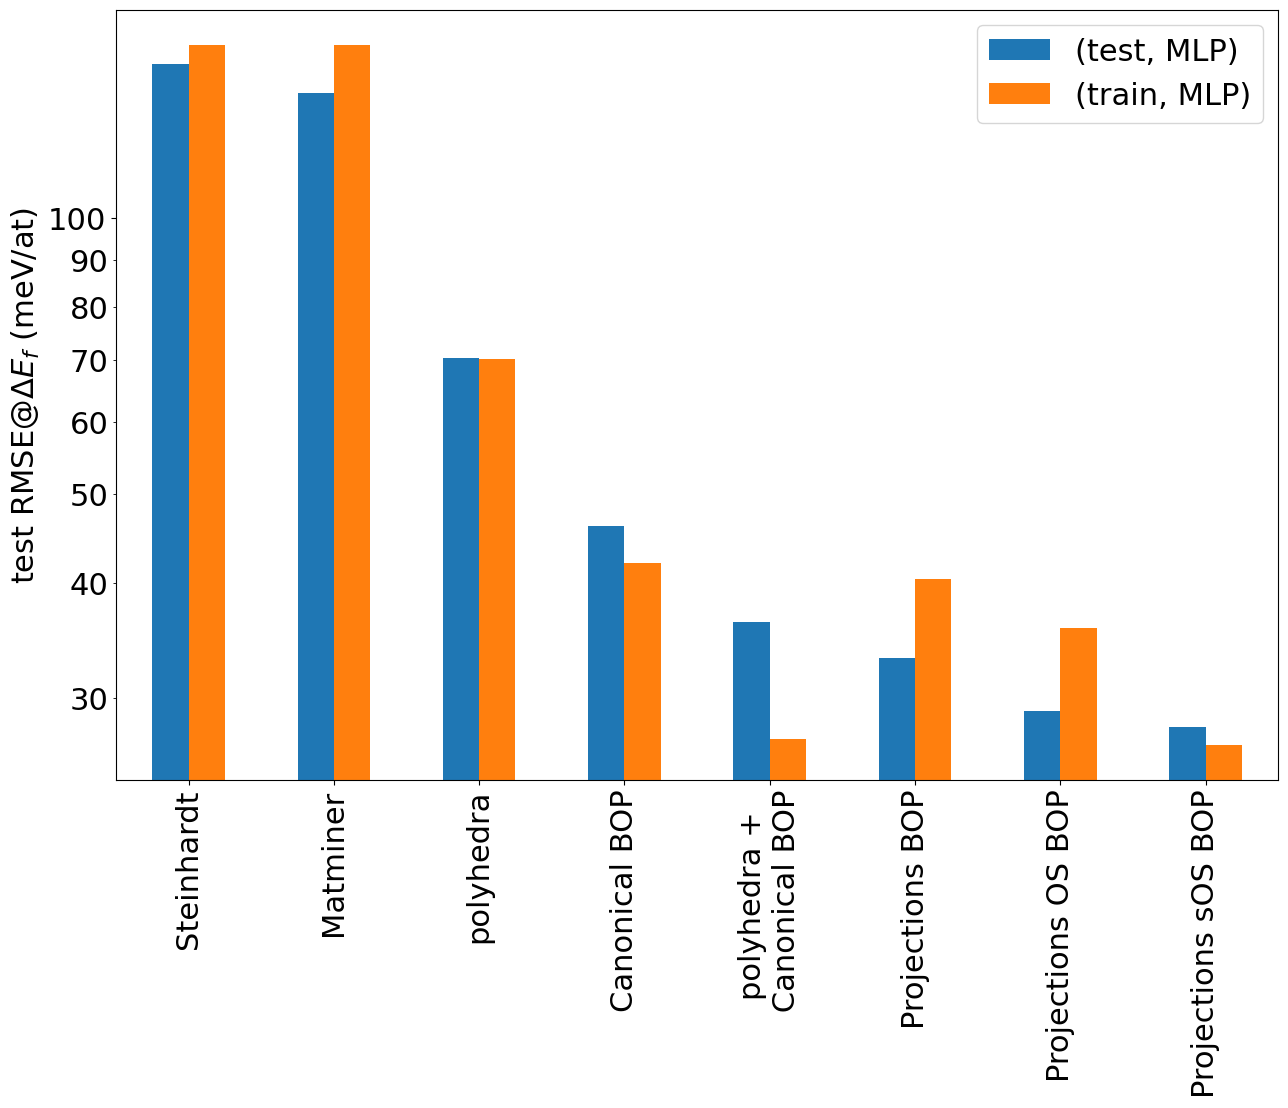

In [76]:
plot_best_scores = SourceFileLoader('plot_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().plot_best_scores

ax = plot_best_scores(OptimalFittedScores, ModelName=ModelName)
ax.tick_params(axis='y', which = 'minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.legend(title='')

# Prediction line 

In [77]:
Prediction = {}
for combi, model in OptimalFittedModels.items():
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    Prediction[combi] = model.predict(X)

In [78]:
#iwanttoplot = {'atomic':'Matminer',
#iwanttoplot = {'Canonical BOP': 'Canonical BOP', 'Projections sOS BOP':'Projections sOS BOP'}
iwanttoplot = {'dataset': 'dataset', 'Projections sOS BOP':'Projections sOS BOP'}

In [79]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


dataset dataset
Projections sOS BOP Projections sOS BOP


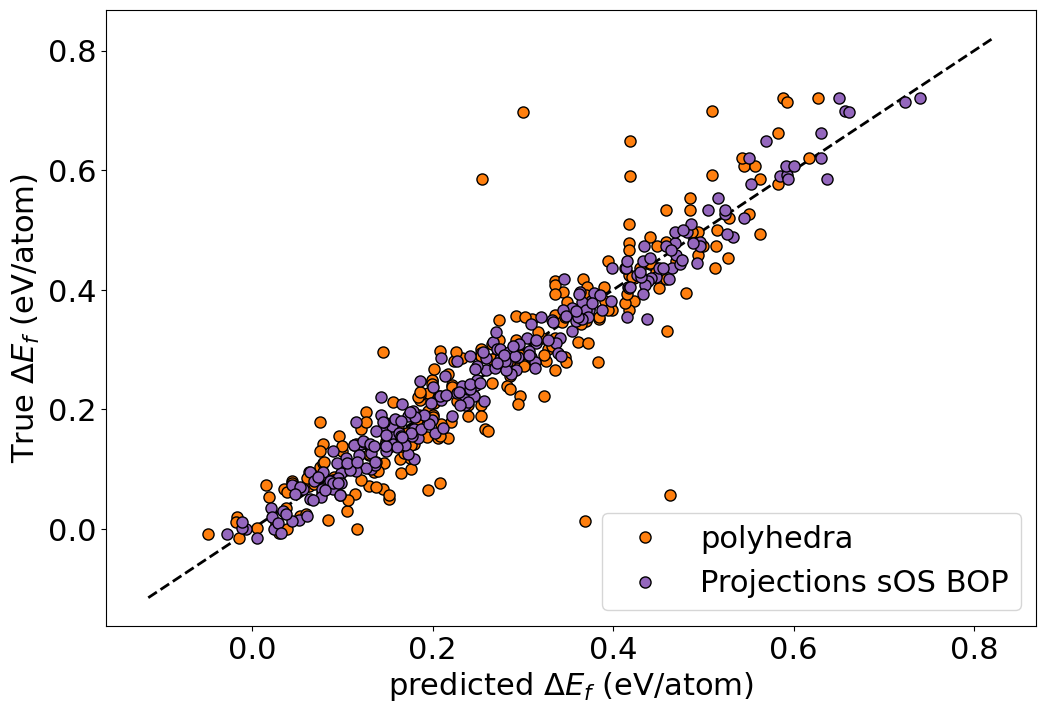

In [80]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi], DS.target, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline.eps'))

# Feature Importances 

In [81]:
importances = {}
for combi, estimator in OptimalFittedModels.items():
    print(combi[1])
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    if 'random' in selected:
        print(f'random selected in {combi}')
    X = DS.Features[combi[1]][selected]
    allimportances = get_importances(estimator , X,  DS.target)
    importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]

atomic
dataset
Pyscal
Canonical BOP
Projections BOP
random selected in ('MLP', 'Projections BOP')
Projections OS BOP
Projections sOS BOP
dataset + Canonical BOP


In [ ]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

In [ ]:
#for (model, name), timp in importances.items():
for (model, name), timp in importances.items(): #['Projections OS BOP', 'dataset + Projections OS BOP']:
#    pimp = timp[timp.index != 'Mag']
    fig, ax = plt.subplots(figsize=(18, 15))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels, fontsize=28)
    fig.suptitle(name.replace('dataset', 'polyhedra'))
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.eps')

# Errors by phase  

In [87]:
combi = (ModelName, 'Projections sOS BOP')

In [88]:
model = OptimalFittedModels[combi]

In [93]:
nselected = FCresults[combi]['test'].argmin()

In [95]:
selected = FCresults[combi].index[:nselected]

In [141]:
predictions = model.predict(DS.Features[combi[1]][selected])

In [204]:
train_errors = np.abs(predictions - DS.target)

In [205]:
rmse = {}

In [215]:
for phase in DS.BS.Phase.unique():
    thiserrors = train_errors[DS.BS.Phase == phase]**2
    rmse[phase] =  np.sqrt(thiserrors.sum()/len(thiserrors))*1000

In [216]:
rmse

{'C36': 30.732802099060216,
 'chi': 19.7379928057643,
 'sigma': 22.267355089511078,
 'hcp': 25.138789459785666,
 'mu': 30.348394836983815,
 'fcc': 18.45463263867396,
 'C14': 29.247237556235277,
 'C15': 27.025242121254067,
 'bcc': 14.6957829994281,
 'A15': 30.899941809445107,
 'R': 31.293381643140897}

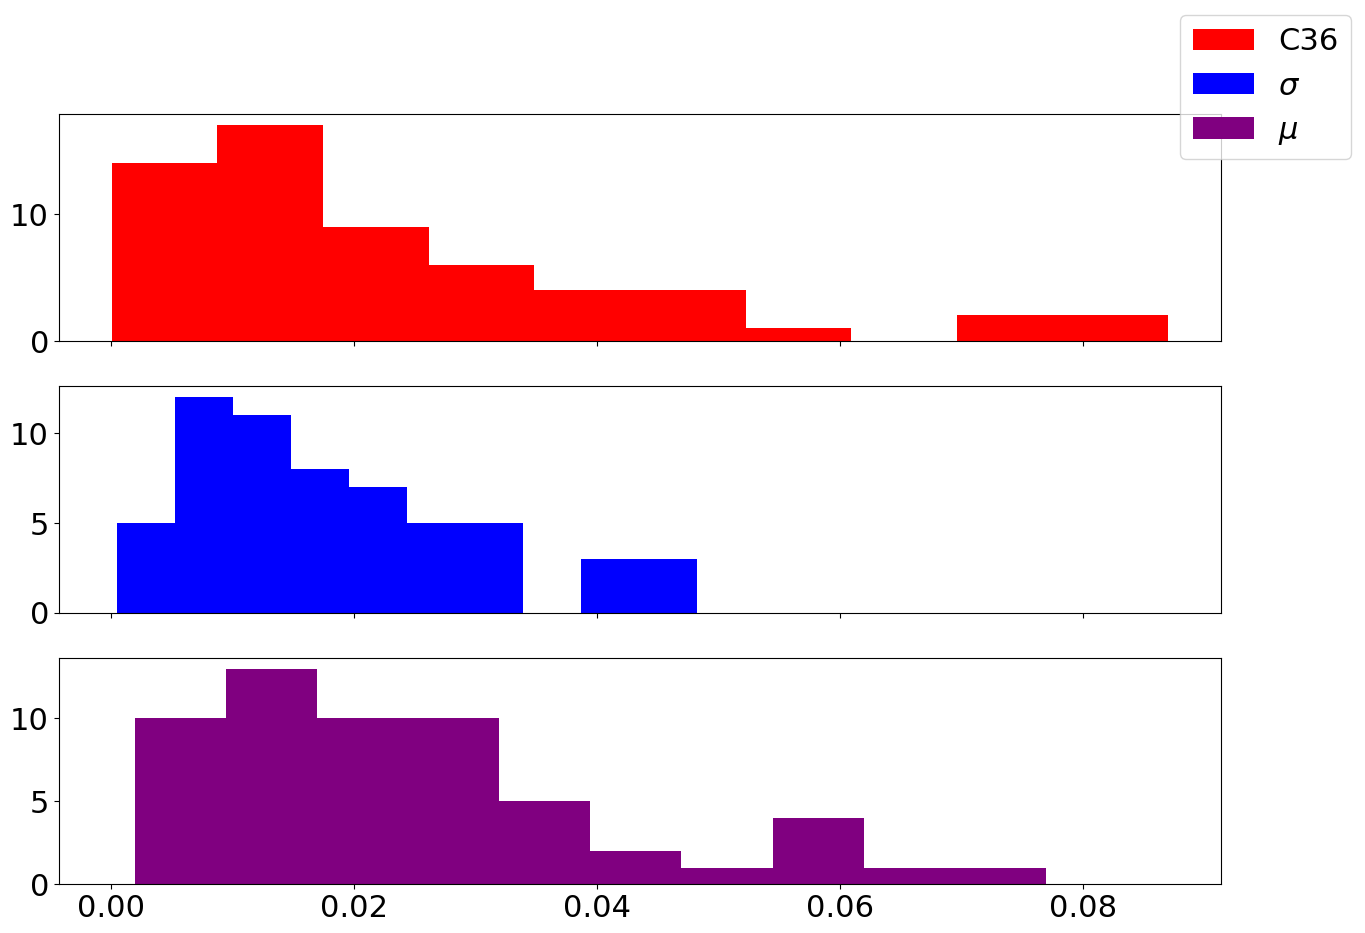

In [217]:
fig, ax = plt.subplots(3, 1, sharex = True)
tphase = ax[0].hist(train_errors[DS.BS.Phase == 'C36'], bins=10, color='red', label='C36')
tphase = ax[1].hist(train_errors[DS.BS.Phase == 'sigma'], bins=10,color='blue', label = r'$\sigma$')
tphase = ax[2].hist(train_errors[DS.BS.Phase == 'mu'], bins=10, color='purple', label = r'$\mu$')
fig.legend()

# convex hulls (binaries only)

In [147]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [148]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [150]:
components = DS.components

In [168]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [169]:
predictedBS['EF'] = Prediction[combi]

In [153]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

PhaseBS = {phase: DS.BS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

points = P.get_x_ef_points(PhaseBS, components)
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False)

In [173]:
PredPhaseBS = {}
Predverts = {}
Predchulls = {}
Predphasepoints = {}

PredPhaseBS = {phase: predictedBS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

predpoints = P.get_x_ef_points(PredPhaseBS, components)
predchulls = P.get_convex_hulls(PredPhaseBS, components, return_points = False)

In [188]:
iwanttoplot = ['R', 'mu', 'C14', 'C36','sigma']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


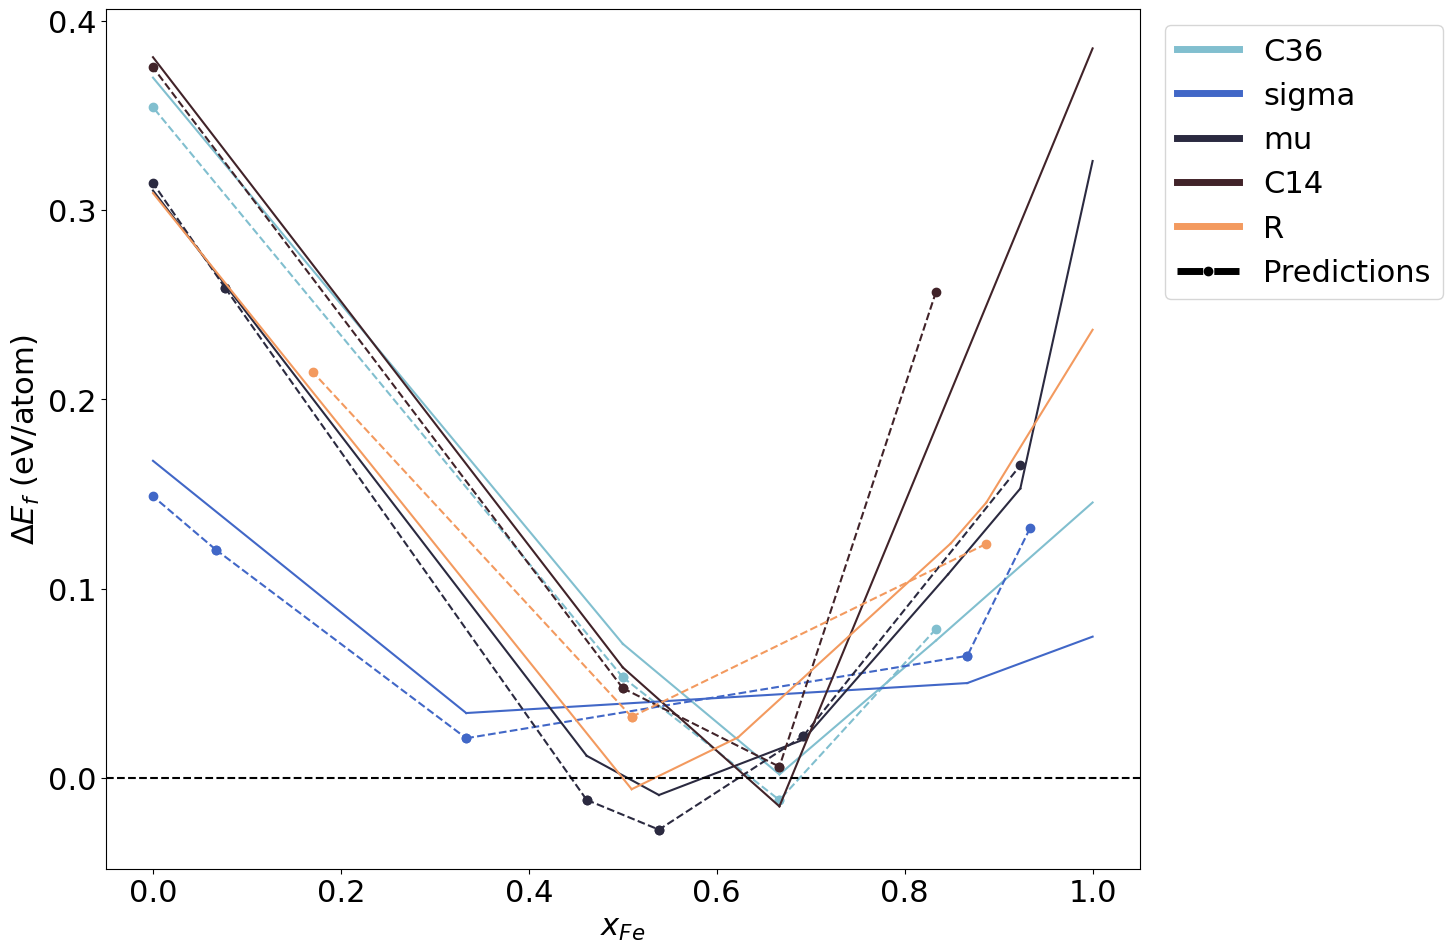

In [221]:
pallette = sns.color_palette("icefire", n_colors=len(PhaseBS))
colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    if phase not in iwanttoplot:
        continue
    for visible_facet in chull.simplices[chull.good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
    handles.append(l[0])
    labels.append(phase)
    for visible_facet in predchulls[phase].simplices[predchulls[phase].good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(predchulls[phase].points[visible_facet,0], predchulls[phase].points[visible_facet,1],'--o', color=colors[phase])
leg = ax.legend(handles +[Line2D([],[], linestyle='--',marker='o', color='black')], labels+['Predictions'], bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')
ax.axhline(color='black', linestyle='--')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs',f'{DS.dataset}_{ModelName}_ConvxHullsFinal.eps' ))